<a href="https://colab.research.google.com/github/roalddalhwriter/isro/blob/main/ElevationNewpipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rasterio sahi ultralytics -q

import rasterio
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel
from rasterio.transform import rowcol
from scipy.ndimage import map_coordinates
from scipy.spatial.distance import cosine
import pandas as pd

print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.1 MB/s eta 0:00:00
✅ Done


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ORTHO_PATH      = '/content/drive/MyDrive/Elevation/PSP_007882_2065_RED_A_01_ORTHO.JP2'
DTM_PATH        = '/content/drive/MyDrive/Elevation/DTEEC_007671_2065_007882_2065_U01.IMG'
YOLO_WEIGHTS    = '/content/drive/MyDrive/Cones/runs/Icelandplusvers/weights/best.pt'
BROWSE_JPG      = '/content/drive/MyDrive/Elevation/ortho_browse.jpg'
REFERENCE_DIR   = '/content/drive/MyDrive/Elevation New/mars'   # your 14 verified cone CSVs
OUTPUT_DIR      = '/content/drive/MyDrive/cones/results_v2/'
SCALE_FACTOR    = 0.0515

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Done')

Mounted at /content/drive
✅ Done


In [4]:
with rasterio.open(DTM_PATH) as src:
    dtm_raw       = src.read(1).astype(np.float32)
    dtm_transform = src.transform
    dtm_nodata    = src.nodata
    scale         = src.scales[0]  if src.scales  else 1.0
    offset        = src.offsets[0] if src.offsets else 0.0

dtm = dtm_raw * scale + offset
if dtm_nodata is not None:
    dtm[dtm_raw == dtm_nodata] = np.nan

DTM_PX_M = abs(dtm_transform.a)
print(f'DTM shape : {dtm.shape}')
print(f'Elevation : {np.nanmin(dtm):.1f} m → {np.nanmax(dtm):.1f} m')
print('✅ DTM loaded')

DTM shape : (12139, 7351)
Elevation : -3231.6 m → -3169.3 m
✅ DTM loaded


In [5]:
with rasterio.open(ORTHO_PATH) as src:
    ortho_transform = src.transform
    ortho_px_m      = abs(ortho_transform.a)

print(f'Ortho resolution: {ortho_px_m:.4f} m/px')
print('✅ Done')

Ortho resolution: 0.2518 m/px
✅ Done


In [6]:
def normalize_profile(elev, n_points=100):
    """Resample to fixed length and normalize 0-1"""
    elev = np.array(elev, dtype=np.float32)
    x_old = np.linspace(0, 1, len(elev))
    x_new = np.linspace(0, 1, n_points)
    resampled = np.interp(x_new, x_old, elev)
    rng = resampled.max() - resampled.min()
    if rng == 0:
        return np.zeros(n_points)
    return (resampled - resampled.min()) / rng

reference_library = []
for f in sorted(Path(REFERENCE_DIR).glob('*.csv')):
    df = pd.read_csv(f)
    df.columns = [c.strip().lower() for c in df.columns]
    elev_col = [c for c in df.columns if 'elev' in c or 'z' in c][0]
    elev = df[elev_col].values

    template = normalize_profile(elev, n_points=100)
    reference_library.append({'name': f.stem, 'template': template})

print(f'✅ Reference library built: {len(reference_library)} verified cone profiles')
for r in reference_library:
    print(f'  {r["name"]}')

✅ Reference library built: 14 verified cone profiles
  1
  10
  11
  12
  13
  14
  2
  3
  4
  5
  6
  7
  8
  9


In [7]:
detection_model = UltralyticsDetectionModel(
    model_path           = YOLO_WEIGHTS,
    confidence_threshold = 0.30,   # loose — DEM comparison does the real filtering
    device               = 'cuda:0'
)

result = get_sliced_prediction(
    BROWSE_JPG,
    detection_model,
    slice_height         = 1260,
    slice_width           = 1260,
    overlap_height_ratio  = 0.2,
    overlap_width_ratio   = 0.2,
    verbose               = 1
)

print(f'✅ Total candidates: {len(result.object_prediction_list)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Performing prediction on 6 slices.
✅ Total candidates: 730


In [8]:
candidates = []
for op in result.object_prediction_list:
    xmin, ymin, xmax, ymax = op.bbox.to_xyxy()
    conf = op.score.value

    cx_browse = (xmin + xmax) / 2.0
    cy_browse = (ymin + ymax) / 2.0
    bbox_w_browse = xmax - xmin

    cx_ortho = cx_browse / SCALE_FACTOR
    cy_ortho = cy_browse / SCALE_FACTOR

    geo_x, geo_y = ortho_transform * (cx_ortho, cy_ortho)
    dtm_r, dtm_c = rowcol(dtm_transform, geo_x, geo_y)

    radius_m   = (bbox_w_browse / 2.0) * (ortho_px_m / SCALE_FACTOR)
    radius_dtm = max(int(radius_m / DTM_PX_M), 15)
    bbox_w_m   = bbox_w_browse * (ortho_px_m / SCALE_FACTOR)

    candidates.append({
        'cx_dtm'    : int(dtm_c),
        'cy_dtm'    : int(dtm_r),
        'radius_dtm': radius_dtm,
        'bbox_w_m'  : bbox_w_m,
        'conf'      : conf
    })

print(f'✅ {len(candidates)} candidates mapped to DTM')

✅ 730 candidates mapped to DTM


In [19]:
def extract_radial_profile(dem, cx, cy, length_px, angle_deg, n_samples=100):
    """Sample elevation along a line at angle_deg from (cx, cy)"""
    angle_rad = np.radians(angle_deg)
    dx = np.cos(angle_rad)
    dy = np.sin(angle_rad)

    t = np.linspace(-length_px, length_px, n_samples)
    cols = cx + t * dx
    rows = cy + t * dy

    rows = np.clip(rows, 0, dem.shape[0] - 1)
    cols = np.clip(cols, 0, dem.shape[1] - 1)

    profile = map_coordinates(dem, [rows, cols], order=1, mode='nearest')
    profile[profile < -9000] = np.nan
    return profile


ANGLES = [i * 11.25 for i in range(16)]   # 16 directions, 0° to 168.75°

for d in candidates:
    length_px = d['radius_dtm'] * 1.5
    profiles = []
    for angle in ANGLES:
        prof = extract_radial_profile(dtm, d['cx_dtm'], d['cy_dtm'], length_px, angle)
        profiles.append(prof)
    d['radial_profiles'] = profiles

print('✅ Radial profiles extracted (16 directions per candidate)')

✅ Radial profiles extracted (16 directions per candidate)


In [20]:
def best_match_similarity_v2(radial_profiles, reference_library, min_prominence=3.0):
    """
    Among all directions, prefer ones that pass structural validation.
    Among structurally valid ones, pick highest cosine similarity.
    If none pass structural validation, return the best cosine match anyway
    but flag it as structurally invalid.
    """
    candidates_info = []

    for i, prof in enumerate(radial_profiles):
        if np.isnan(prof).mean() > 0.2:
            continue
        valid = ~np.isnan(prof)
        if valid.sum() < len(prof) * 0.5:
            continue
        p = np.interp(np.arange(len(prof)), np.where(valid)[0], prof[valid])

        struct_valid, struct_info = validate_cone_structure(p, min_prominence=min_prominence)

        norm_p = normalize_profile(p, n_points=100)
        best_sim = -1
        best_ref = None
        for ref in reference_library:
            sim = 1 - cosine(norm_p, ref['template'])
            if sim > best_sim:
                best_sim = sim
                best_ref = ref['name']

        candidates_info.append({
            'angle_idx'   : i,
            'struct_valid': struct_valid,
            'struct_info' : struct_info,
            'similarity'  : best_sim,
            'ref_match'   : best_ref
        })

    if not candidates_info:
        return None

    # Prefer structurally valid directions
    valid_dirs = [c for c in candidates_info if c['struct_valid']]
    if valid_dirs:
        best = max(valid_dirs, key=lambda c: c['similarity'])
        best['used_structural_fallback'] = False
    else:
        best = max(candidates_info, key=lambda c: c['similarity'])
        best['used_structural_fallback'] = True

    return best


for d in candidates:
    best = best_match_similarity_v2(d['radial_profiles'], reference_library, min_prominence=3.0)
    if best is None:
        d['similarity_score']  = -1
        d['struct_valid']      = False
        d['best_angle_idx']    = None
        d['best_ref_match']    = None
    else:
        d['similarity_score']  = best['similarity']
        d['struct_valid']      = best['struct_valid']
        d['best_angle_idx']    = best['angle_idx']
        d['best_angle_deg']    = ANGLES[best['angle_idx']]
        d['best_ref_match']    = best['ref_match']
        d['used_fallback']     = best['used_structural_fallback']

print('✅ Similarity + structural validation computed for all candidates (16 directions)')

# Summary
total = len(candidates)
struct_pass = sum(1 for d in candidates if d.get('struct_valid'))
fallback_used = sum(1 for d in candidates if d.get('used_fallback'))

print(f'\nTotal candidates           : {total}')
print(f'Structurally valid (some dir): {struct_pass}')
print(f'No valid direction found    : {fallback_used}')

scores_valid = [d['similarity_score'] for d in candidates if d.get('struct_valid')]
if scores_valid:
    print(f'\nAmong structurally valid candidates:')
    print(f'  Min similarity  : {np.min(scores_valid):.3f}')
    print(f'  Max similarity  : {np.max(scores_valid):.3f}')
    print(f'  Mean similarity : {np.mean(scores_valid):.3f}')

✅ Similarity + structural validation computed for all candidates (16 directions)

Total candidates           : 730
Structurally valid (some dir): 146
No valid direction found    : 584

Among structurally valid candidates:
  Min similarity  : 0.586
  Max similarity  : 0.996
  Mean similarity : 0.950


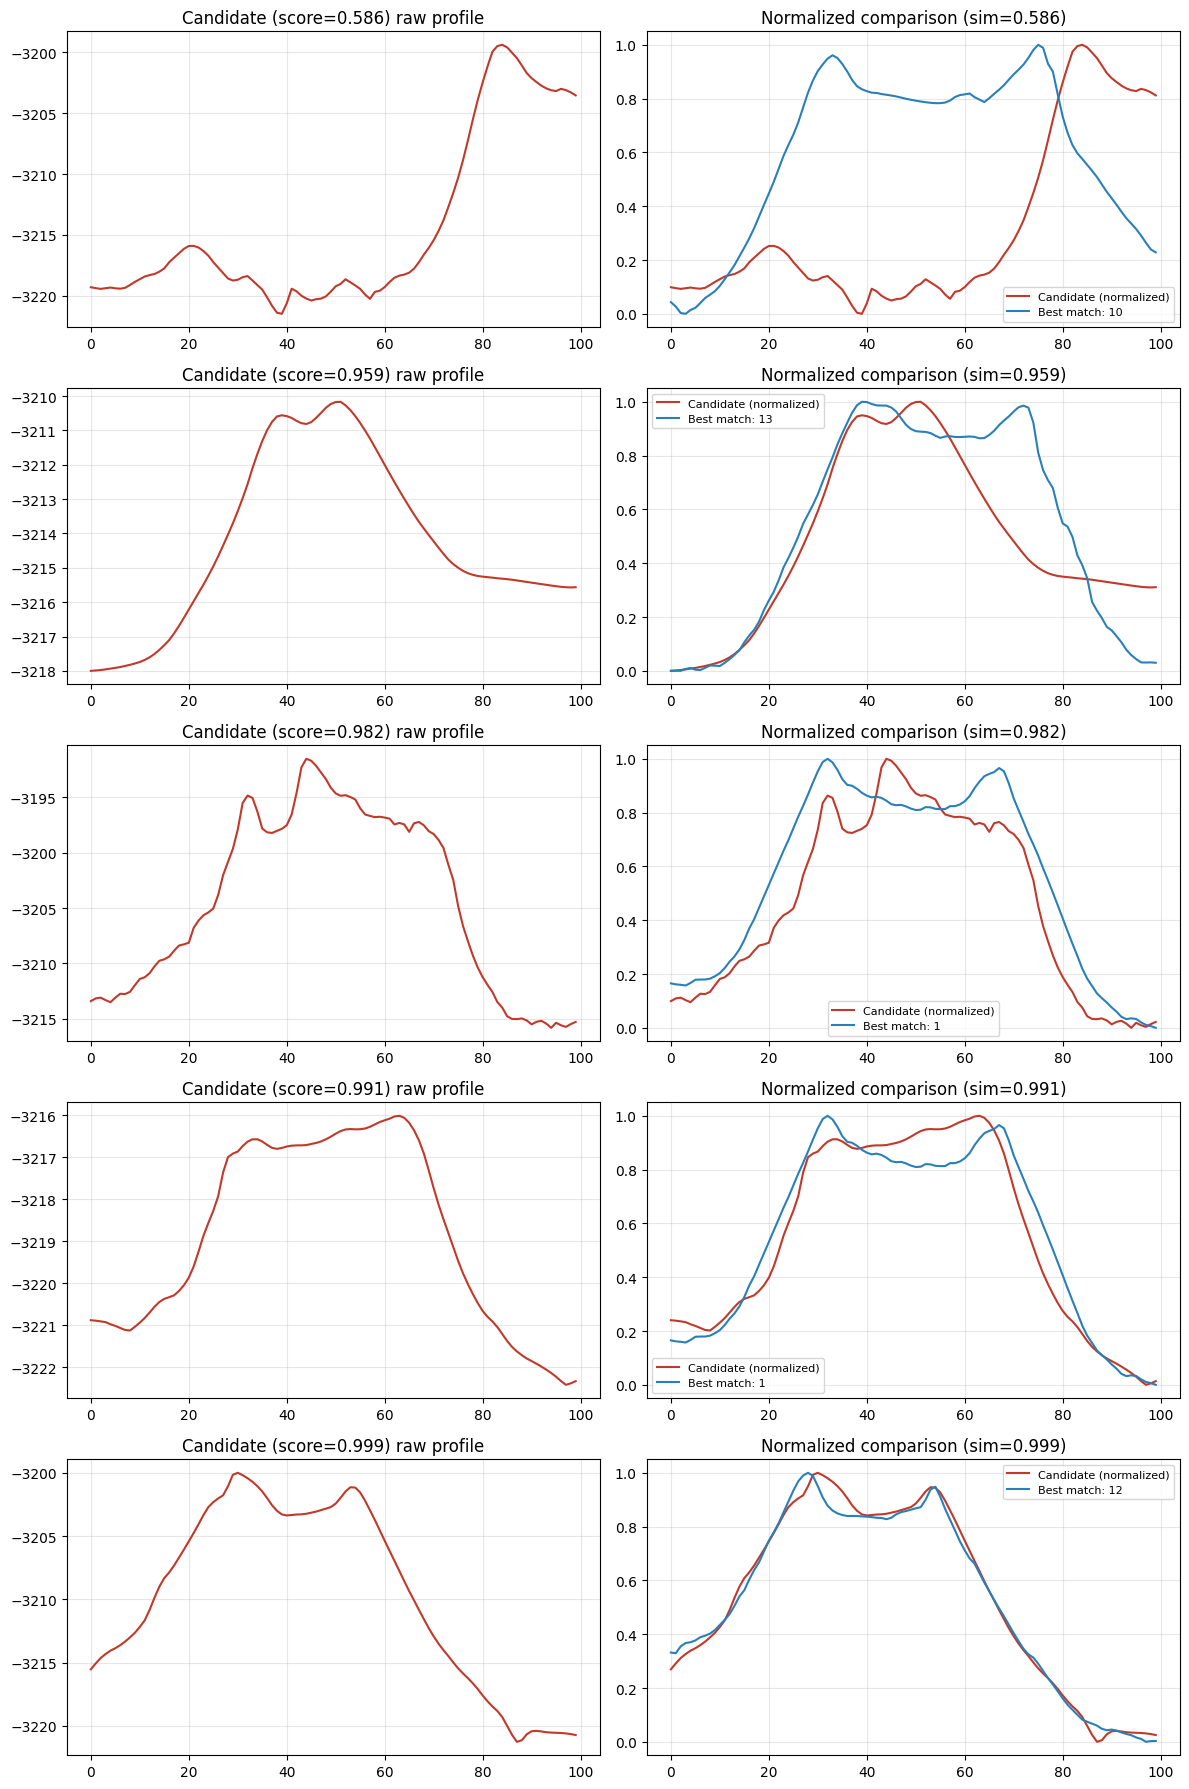

✅ Saved diagnostic plot


In [21]:
import random

# Pick samples across the score range
sorted_candidates = sorted(candidates, key=lambda d: d['similarity_score'])
sample_indices = [0, len(sorted_candidates)//4, len(sorted_candidates)//2,
                   3*len(sorted_candidates)//4, len(sorted_candidates)-1]

fig, axes = plt.subplots(5, 2, figsize=(12, 18))

for row, idx in enumerate(sample_indices):
    d = sorted_candidates[idx]
    angle_idx = d['best_angle_idx']

    if angle_idx is None:
        continue

    prof = d['radial_profiles'][angle_idx]
    valid = ~np.isnan(prof)
    p = np.interp(np.arange(len(prof)), np.where(valid)[0], prof[valid])
    norm_p = normalize_profile(p, n_points=100)

    ref_template = [r['template'] for r in reference_library if r['name'] == d['best_ref_match']][0]

    axes[row, 0].plot(p, color='#c0392b')
    axes[row, 0].set_title(f'Candidate (score={d["similarity_score"]:.3f}) raw profile')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(norm_p, color='#c0392b', label='Candidate (normalized)')
    axes[row, 1].plot(ref_template, color='#2980b9', label=f'Best match: {d["best_ref_match"]}')
    axes[row, 1].set_title(f'Normalized comparison (sim={d["similarity_score"]:.3f})')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'similarity_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved diagnostic plot')

In [24]:
THRESHOLD = 0.99

cone_classified = [d for d in candidates if d['similarity_score'] >= THRESHOLD]
print(f'✅ Classified as rootless cones: {len(cone_classified)} out of {len(candidates)} candidates')

os.makedirs(OUTPUT_DIR + 'classified_cones/', exist_ok=True)

for i, d in enumerate(cone_classified):
    angle_idx = d['best_angle_idx']
    prof = d['radial_profiles'][angle_idx]
    angle = d['best_angle_deg']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # DTM chip
    half = d['radius_dtm'] * 2
    r0 = max(0, d['cy_dtm'] - half);  r1 = min(dtm.shape[0], d['cy_dtm'] + half)
    c0 = max(0, d['cx_dtm'] - half);  c1 = min(dtm.shape[1], d['cx_dtm'] + half)
    chip = dtm[r0:r1, c0:c1]
    axes[0].imshow(chip, cmap='terrain',
                   vmin=np.nanpercentile(chip, 2),
                   vmax=np.nanpercentile(chip, 98))
    axes[0].plot(d['cx_dtm'] - c0, d['cy_dtm'] - r0, 'r+', markersize=10, mew=2)

    # Draw the matched profile direction as a line
    length_px = d['radius_dtm'] * 1.5
    angle_rad = np.radians(angle)
    dx, dy = np.cos(angle_rad), np.sin(angle_rad)
    x1, y1 = d['cx_dtm'] - c0 - length_px*dx, d['cy_dtm'] - r0 - length_px*dy
    x2, y2 = d['cx_dtm'] - c0 + length_px*dx, d['cy_dtm'] - r0 + length_px*dy
    axes[0].plot([x1, x2], [y1, y2], color='cyan', linewidth=1.2, alpha=0.8)

    axes[0].set_title(f'Cone {i} | conf={d["conf"]:.2f} | angle={angle}°', fontsize=9)
    axes[0].axis('off')

    # Profile
    valid = ~np.isnan(prof)
    p = np.interp(np.arange(len(prof)), np.where(valid)[0], prof[valid])
    dist_m = np.linspace(-d['radius_dtm']*1.5*DTM_PX_M, d['radius_dtm']*1.5*DTM_PX_M, len(p))

    axes[1].plot(dist_m, p, color='#c0392b', lw=1.5)
    axes[1].set_xlabel('Distance (m)')
    axes[1].set_ylabel('Elevation (m)')
    axes[1].set_title(f'Best match: {d["best_ref_match"]} | similarity={d["similarity_score"]:.3f}', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Cone {i} | size={d["bbox_w_m"]:.0f}m | conf={d["conf"]:.2f}', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'classified_cones/cone_{i:03d}_sim{d["similarity_score"]:.3f}.png',
                dpi=120, bbox_inches='tight')
    plt.close(fig)

    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{len(cone_classified)}] saved')

print(f'\n✅ All {len(cone_classified)} classified cone profiles saved to {OUTPUT_DIR}classified_cones/')

✅ Classified as rootless cones: 202 out of 730 candidates
  [50/202] saved
  [100/202] saved
  [150/202] saved
  [200/202] saved

✅ All 202 classified cone profiles saved to /content/drive/MyDrive/cones/results_v2/classified_cones/
